In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from scipy import stats 


# Compare 50Hz model to main feature-gain model per condition

## Analysis:
For each background condition, average across SNRs and plot difference in accuracy, a,  between both:  $a_{\text{main model}} - a_{\text{50 Hz cutoff}}$

### Get data

In [28]:
### Import pre-formated data 

results_dir = Path('final_results_dir')

# diotic SWC 
diotic_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_SWC_diotic_conditions_humans_N-195_models_v10_w_control_archs_and_50Hz.pdpkl")
diotic_results['experiment'] = 'Diotic'

# Popham SWC
popham_results = pd.read_pickle(results_dir / "df_for_stats_2024_SWC_popham_conditions_humans_N-90_models_v10_w_control_archs_w_50Hz.pdpkl")
popham_results.loc[popham_results.group.str.contains("Human"), 'model'] = popham_results.loc[popham_results.group.str.contains("Human"), 'group']
popham_results['snr'] = 0 # add snr column to match diotic_results
popham_conds_to_keep = ['Harmonic_target_Harmonic_distractor',
                        'Harmonic_target_No Distractor_distractor',
                        'Inharmonic_target_Inharmonic_distractor',
                        'Inharmonic_target_No Distractor_distractor',
                        'Whispered_target_No Distractor_distractor',
                        'Whispered_target_Whispered_distractor']

popham_results = popham_results[popham_results['background_condition'].isin(popham_conds_to_keep)].reset_index(drop=True)
popham_results['experiment'] = 'Harmonicity'
# threshold results 
threshold_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_thresholds_humans_N-33_models_v10_w_control_archs_w50Hz.pdpkl")
threshold_results['background_condition'] = threshold_results['azim_delta'].astype('str') + ' azim delta ' + threshold_results['elev_delta'].astype('str') + ' elev delta' 
threshold_results['experiment'] = 'Threshold'

# Spotlight results 
spotlight_results = pd.read_pickle(results_dir / "df_for_stats_and_summary_2024_spotlight_humans_N-28_models_v10_w_control_archs_w50Hz.pdpkl")
spotlight_results['snr'] = 0 
spotlight_results['background_condition'] = spotlight_results['target_azim'].astype('str') + ' target azim ' + spotlight_results['azim_delta'].astype('str') + ' azim delta'
spotlight_results['experiment'] = 'Spotlight'


In [29]:
combined_results.group.unique()

array(['Feature-gain Model', '50Hz cutoff',
       'word_task_v10_main_feature_gain_config'], dtype=object)

In [30]:
combined_results = pd.concat([diotic_results, popham_results, threshold_results,spotlight_results ], axis=0) # spotlight_results
## update model names for comparison 

combined_results = combined_results[combined_results.model.str.contains('main|50Hz')].copy()
combined_results.loc[combined_results['model'].str.contains("50Hz"), ['model', 'group']] = '50Hz cutoff'


In [31]:
combined_results.group.value_counts()

group
Feature-gain Model    100
50Hz cutoff           100
Name: count, dtype: int64

In [32]:
## Get condition dict for colors in baplot

experiment_conditions = {exp_key: combined_results[combined_results['experiment'] == exp_key]['background_condition'].unique() for exp_key in combined_results['experiment'].unique()}

condition_to_experiment = {}
for exp_key in experiment_conditions:
    for cond in experiment_conditions[exp_key]:
        condition_to_experiment[cond] = exp_key

In [33]:
summary = combined_results.groupby(['group', 'background_condition']).agg({"accuracy": "mean", "confusions":"mean"}).reset_index()
summary['experiment'] = summary['background_condition'].map(condition_to_experiment)


In [70]:
diff_df['condition'].values

array(['1-talker', '2-talker', '4-talker', 'Different sex', 'English',
       'Mandarin', 'Same sex', 'Babble', 'Clean', 'Music',
       'Natural scene', 'Noise', 'Harmonic with distractor',
       'Harmonic single talker', 'Inharmonic with distractor',
       'Inharmonic single talker', 'Whispered single talker',
       'Whispered with distractor', '0 target azim 0 azim delta',
       '0 target azim 10 azim delta', '0 target azim 30 azim delta',
       '0 target azim 90 azim delta', '90 target azim 0 azim delta',
       '90 target azim 10 azim delta', '90 target azim 30 azim delta',
       '90 target azim 90 azim delta', '0 azim delta 0 elev delta',
       '0 azim delta 10 elev delta', '0 azim delta 60 elev delta',
       '10 azim delta 0 elev delta', '60 azim delta 0 elev delta'],
      dtype=object)

/tmp/ipykernel_3447775/2517857059.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90, horizontalalignment='center');


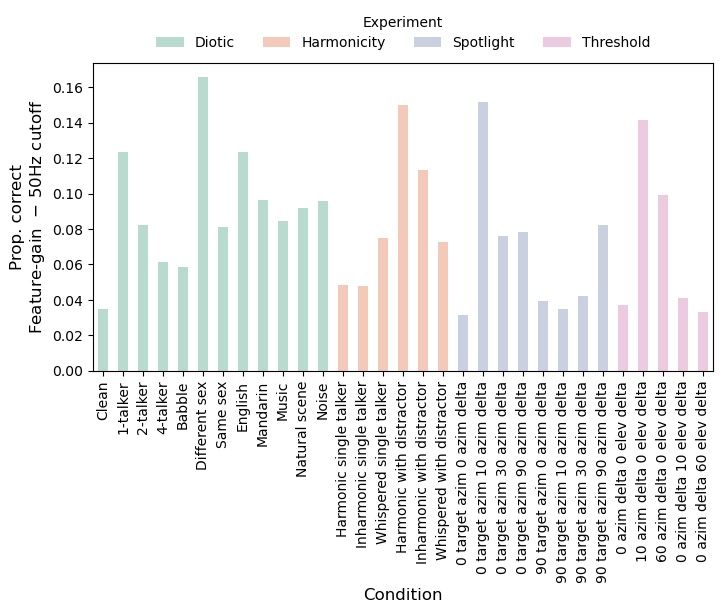

In [73]:
# get difference between feature-gain model and 50Hz cutoff model

fba_results = summary[summary['group'].str.contains('Feature')].copy().sort_values(by=['background_condition'])
cutoff_50_df = summary[summary['group'] == '50Hz cutoff'].copy().sort_values(by=['background_condition'])

diffs = fba_results['accuracy'].values - cutoff_50_df['accuracy'].values
diff_df = pd.DataFrame(diffs, columns=['accuracy_diff'])
diff_df['condition'] = fba_results['background_condition'].values
diff_df['experiment'] = fba_results['experiment'].values
diff_df.sort_values(by=['experiment', 'condition'], inplace=True)
# change condition names for plotting 
diff_df['condition'] = diff_df['condition'].replace({'Harmonic_target_Harmonic_distractor': 'Harmonic with distractor',
                                                    'Harmonic_target_No Distractor_distractor': 'Harmonic single talker',
                                                    'Inharmonic_target_Inharmonic_distractor': 'Inharmonic with distractor',
                                                    'Inharmonic_target_No Distractor_distractor': 'Inharmonic single talker',
                                                    'Whispered_target_No Distractor_distractor': 'Whispered single talker',
                                                    'Whispered_target_Whispered_distractor': 'Whispered with distractor',
                                                    'Different': 'Different sex',
                                                    'Same': 'Same sex',
                                                })

condition_order =  ['Clean','1-talker', '2-talker', '4-talker', 'Babble', 'Different sex', 'Same sex', 'English',
    'Mandarin', 
    'Music',
    'Natural scene', 'Noise',
    'Harmonic single talker',
    'Inharmonic single talker', 
    'Whispered single talker',
    'Harmonic with distractor',
    'Inharmonic with distractor',
    'Whispered with distractor', 
    '0 target azim 0 azim delta',
    '0 target azim 10 azim delta',
    '0 target azim 30 azim delta',
    '0 target azim 90 azim delta', 
    '90 target azim 0 azim delta',
    '90 target azim 10 azim delta',
    '90 target azim 30 azim delta',
    '90 target azim 90 azim delta',
    '0 azim delta 0 elev delta',
    '10 azim delta 0 elev delta',
    '60 azim delta 0 elev delta',
    '0 azim delta 10 elev delta', 
    '0 azim delta 60 elev delta',
        ]


diff_df['condition'] = diff_df['condition'].str.capitalize()

## add bar plot 
aspect = 4
fontsize=12

fig, ax = plt.subplots(figsize=( 2 * aspect, aspect))

bar_width = 0.5


g = sns.barplot(data=diff_df, x='condition', order=condition_order, y='accuracy_diff', hue='experiment',  alpha=0.5, width=bar_width, ax=ax, palette='Set2')
g.set_xticklabels(g.get_xticklabels(), rotation=90, horizontalalignment='center');
g.set_xlabel('Condition', fontsize=fontsize);
g.set_ylabel("Prop. correct\nFeature-gain  $-$ 50Hz cutoff", fontsize=fontsize)
# g.legend(title='Experiment', frameon=False, bbox_to_anchor=(1,1))
sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title="Experiment", frameon=False,
)
